# EPL Foul Win Probability Model

# Phase 3 – Feature Engineering

## Objective

This notebook transforms the target dataset into a machine learning-ready dataset.

The notebook performs the following tasks:

- Load the processed target dataset
- Create engineered features
- Validate engineered features
- Explore feature distributions
- Analyze feature correlations
- Save the engineered dataset for model training

In [3]:
from pathlib import Path
import sys

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root)
)

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from src.feature_engineering import FeatureEngineer

## Load Target Dataset

In [5]:
dataset = pd.read_csv(
    "../data/processed/model_dataset.csv"
)

print(dataset.shape)

(381267, 50)


In [6]:
dataset.head()

,Unnamed: 0,id,index,period,timestamp,minute,second,possession,duration,related_events,...,dribble.outcome.id,dribble.outcome.name,ball_receipt.outcome.id,ball_receipt.outcome.name,carry.end_location,duel.outcome.id,duel.outcome.name,competition_id,match_id,target
0,88200,e7f3536d-3209-4ed2-a3a4-cd1519e44f7f,6,1,00:00:00.898,0,0,2,NaN,b1c7e9af-19b2-47d8-855f-14aa3209648c,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3753972,0
1,88203,ec0b4585-41ad-4ada-817c-629d0866eeeb,9,1,00:00:01.808,0,1,2,NaN,"575d8b5a-1b10-4f34-98df-579cc0a52a2e, 70fc4868...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3753972,0
2,88206,5244092d-6381-41a2-9ea8-727bc84aa5e6,12,1,00:00:04.502,0,4,2,NaN,3d440f32-9181-4e21-8d9d-f6993914f36c,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3753972,0
3,88209,38650027-fd3b-42be-8fc3-d1a23c617665,15,1,00:00:06.655,0,6,2,NaN,234fa315-2c07-44f5-a31b-d993a98ce386,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3753972,0
4,88212,133fb108-6aff-45d7-8311-770dfc2d4810,18,1,00:00:10.480,0,10,2,NaN,f50a6695-4769-4c8b-a0cf-473df4d91dcf,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3753972,0


In [7]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 381267 entries, 0 to 381266
Data columns (total 50 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Unnamed: 0                 381267 non-null  int64  
 1   id                         381267 non-null  str    
 2   index                      381267 non-null  int64  
 3   period                     381267 non-null  int64  
 4   timestamp                  381267 non-null  str    
 5   minute                     381267 non-null  int64  
 6   second                     381267 non-null  int64  
 7   possession                 381267 non-null  int64  
 8   duration                   40943 non-null   float64
 9   related_events             360011 non-null  str    
 10  location                   381267 non-null  str    
 11  under_pressure             34829 non-null   object 
 12  counterpress               0 non-null       float64
 13  type.id                    381267 non-nu

## Feature Engineering

In [8]:
engineer = FeatureEngineer()

dataset = engineer.create_features(dataset)

2026-07-08 22:35:03 | INFO | Starting feature engineering...
2026-07-08 22:35:03 | INFO | Extracting location coordinates...
2026-07-08 22:35:04 | INFO | Creating distance to goal feature...
2026-07-08 22:35:04 | INFO | Creating goal angle feature...
2026-07-08 22:35:04 | INFO | Creating pitch zones...
2026-07-08 22:35:04 | INFO | Encoding event types...
2026-07-08 22:35:04 | INFO | Creating match time feature...
2026-07-08 22:35:04 | INFO | Feature engineering completed successfully.
2026-07-08 22:35:04 | INFO | Current dataset shape: (381267, 57)


In [9]:
print(dataset.shape)

(381267, 57)


In [10]:
dataset.head()

,Unnamed: 0,id,index,period,timestamp,minute,second,possession,duration,related_events,...,competition_id,match_id,target,x,y,distance_to_goal,goal_angle,pitch_zone,event_type,match_time_seconds
0,88200,e7f3536d-3209-4ed2-a3a4-cd1519e44f7f,6,1,00:00:00.898,0,0,2,NaN,b1c7e9af-19b2-47d8-855f-14aa3209648c,...,2,3753972,0,60.2,40.7,59.804097,-0.670656,Middle,0,0
1,88203,ec0b4585-41ad-4ada-817c-629d0866eeeb,9,1,00:00:01.808,0,1,2,NaN,"575d8b5a-1b10-4f34-98df-579cc0a52a2e, 70fc4868...",...,2,3753972,0,52.4,41.6,67.618932,-1.355860,Middle,0,1
2,88206,5244092d-6381-41a2-9ea8-727bc84aa5e6,12,1,00:00:04.502,0,4,2,NaN,3d440f32-9181-4e21-8d9d-f6993914f36c,...,2,3753972,0,33.2,60.9,89.280737,-13.538167,Defensive,0,4
3,88209,38650027-fd3b-42be-8fc3-d1a23c617665,15,1,00:00:06.655,0,6,2,NaN,234fa315-2c07-44f5-a31b-d993a98ce386,...,2,3753972,0,28.5,31.1,91.931823,5.555556,Defensive,0,6
4,88212,133fb108-6aff-45d7-8311-770dfc2d4810,18,1,00:00:10.480,0,10,2,NaN,f50a6695-4769-4c8b-a0cf-473df4d91dcf,...,2,3753972,0,26.8,60.2,95.363934,-12.229037,Defensive,0,10


## Engineered Features

In [11]:
new_features = [

    "x",

    "y",

    "distance_to_goal",

    "goal_angle",

    "pitch_zone",

    "event_type",

    "match_time_seconds",

]

dataset[new_features].head()

,x,y,distance_to_goal,goal_angle,pitch_zone,event_type,match_time_seconds
0,60.2,40.7,59.804097,-0.670656,Middle,0,0
1,52.4,41.6,67.618932,-1.355860,Middle,0,1
2,33.2,60.9,89.280737,-13.538167,Defensive,0,4
3,28.5,31.1,91.931823,5.555556,Defensive,0,6
4,26.8,60.2,95.363934,-12.229037,Defensive,0,10


## Dataset Information

In [12]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 381267 entries, 0 to 381266
Data columns (total 57 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Unnamed: 0                 381267 non-null  int64  
 1   id                         381267 non-null  str    
 2   index                      381267 non-null  int64  
 3   period                     381267 non-null  int64  
 4   timestamp                  381267 non-null  str    
 5   minute                     381267 non-null  int64  
 6   second                     381267 non-null  int64  
 7   possession                 381267 non-null  int64  
 8   duration                   40943 non-null   float64
 9   related_events             360011 non-null  str    
 10  location                   381267 non-null  str    
 11  under_pressure             34829 non-null   object 
 12  counterpress               0 non-null       float64
 13  type.id                    381267 non-nu

In [15]:
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,381267.0,6.554588e+05,379100.905621,6.000000e+00,3.272575e+05,6.544580e+05,9.835810e+05,1.313781e+06
index,381267.0,1.728393e+03,1017.164636,6.000000e+00,8.510000e+02,1.710000e+03,2.579000e+03,4.262000e+03
period,381267.0,1.488416e+00,0.499866,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00
minute,381267.0,4.462835e+01,27.029716,0.000000e+00,2.100000e+01,4.500000e+01,6.700000e+01,1.000000e+02
second,381267.0,2.928226e+01,17.350862,0.000000e+00,1.400000e+01,2.900000e+01,4.400000e+01,5.900000e+01
possession,381267.0,9.261850e+01,54.948467,2.000000e+00,4.500000e+01,9.100000e+01,1.380000e+02,2.380000e+02
duration,40943.0,5.594788e-04,0.025921,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.623528e+00
counterpress,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type.id,381267.0,3.770453e+01,12.384186,2.000000e+00,4.200000e+01,4.200000e+01,4.200000e+01,4.200000e+01
possession_team.id,381267.0,3.174735e+01,12.278757,1.000000e+00,2.500000e+01,3.000000e+01,3.800000e+01,5.900000e+01


## Missing Values

In [18]:
dataset.isnull().sum().sort_values(
    ascending=False
).head(20)

counterpress            381267
tactics.lineup          381267
tactics.formation       381267
pass.body_part.name     381267
pass.body_part.id       381267
pass.height.id          381267
pass.height.name        381267
duel.outcome.id         381267
duel.outcome.name       381267
dribble.outcome.name    381267
carry.end_location      381267
dribble.outcome.id      381267
pass.end_location       381267
pass.outcome.name       381267
pass.outcome.id         381267
pass.recipient.name     381267
pass.receipient.id      381267
pass.type.id            381267
pass.type.name          381267
pass.length             381267
dtype: int64

## Pitch Zone Distribution

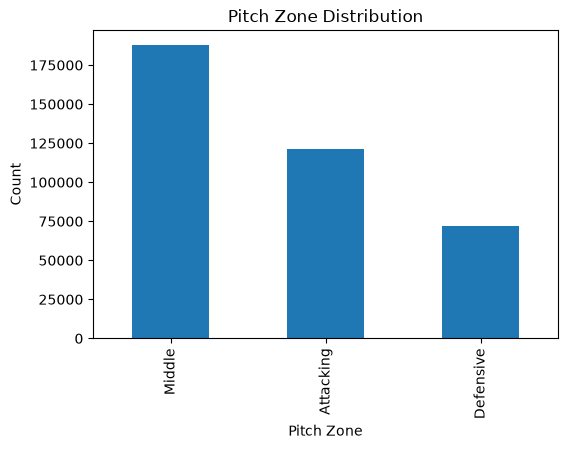

In [19]:
plt.figure(figsize=(6,4))

dataset["pitch_zone"]\
    .value_counts()\
    .plot(
        kind="bar"
    )

plt.title("Pitch Zone Distribution")

plt.xlabel("Pitch Zone")

plt.ylabel("Count")

plt.show()

## Event Type Distribution

In [20]:
dataset["type.name"].value_counts()

type.name
Ball Receipt*    340324
Ball Recovery     40943
Name: count, dtype: int64

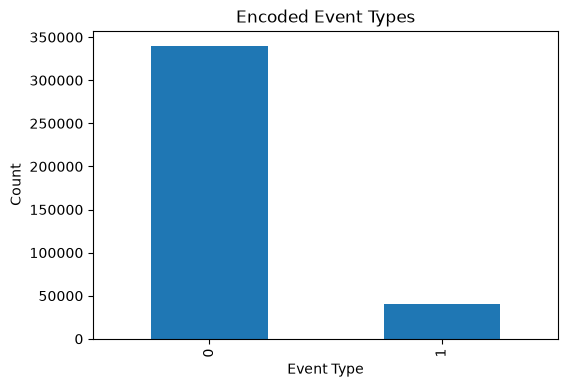

In [21]:
plt.figure(figsize=(6,4))

dataset["event_type"]\
    .value_counts()\
    .plot(kind="bar")

plt.title("Encoded Event Types")

plt.xlabel("Event Type")

plt.ylabel("Count")

plt.show()

## Distance to Goal

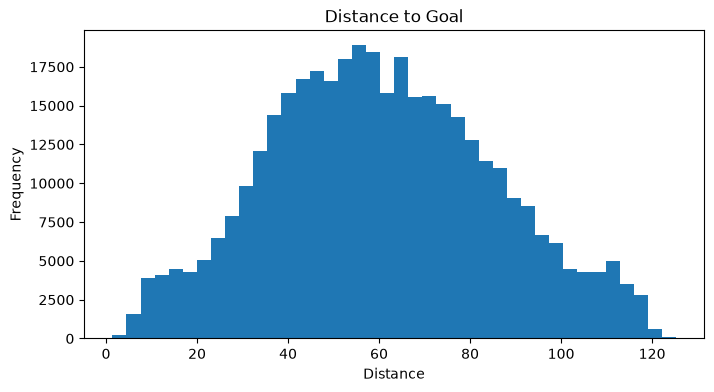

In [22]:
plt.figure(figsize=(8,4))

plt.hist(
    dataset["distance_to_goal"],
    bins=40,
)

plt.title("Distance to Goal")

plt.xlabel("Distance")

plt.ylabel("Frequency")

plt.show()

## Goal Angle

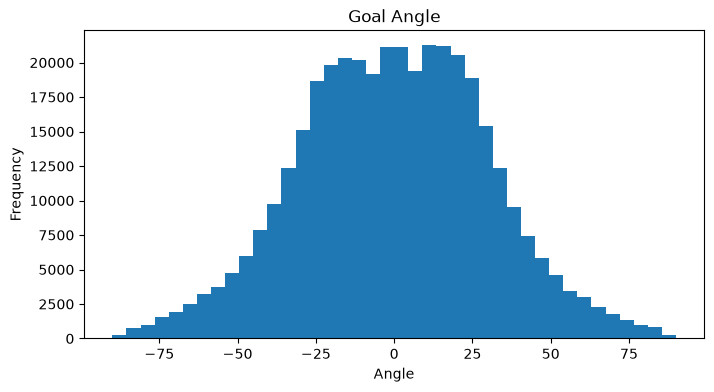

In [24]:
plt.figure(figsize=(8,4))

plt.hist(
    dataset["goal_angle"],
    bins=40,
)

plt.title("Goal Angle")

plt.xlabel("Angle")

plt.ylabel("Frequency")

plt.show()

## Match Time Distribution

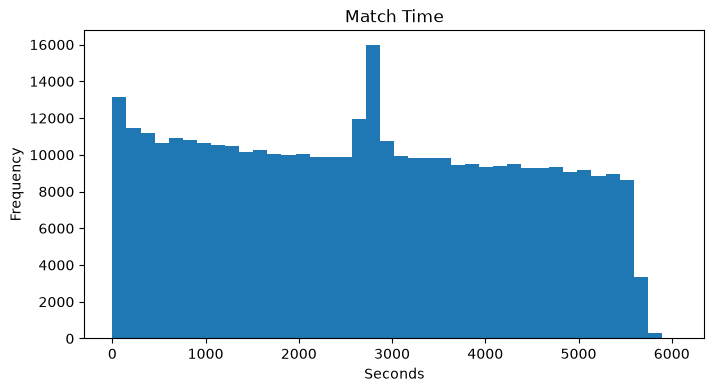

In [25]:
plt.figure(figsize=(8,4))

plt.hist(
    dataset["match_time_seconds"],
    bins=40,
)

plt.title("Match Time")

plt.xlabel("Seconds")

plt.ylabel("Frequency")

plt.show()

## Target Distribution

In [26]:
dataset["target"].value_counts()

target
0    372581
1      8686
Name: count, dtype: int64

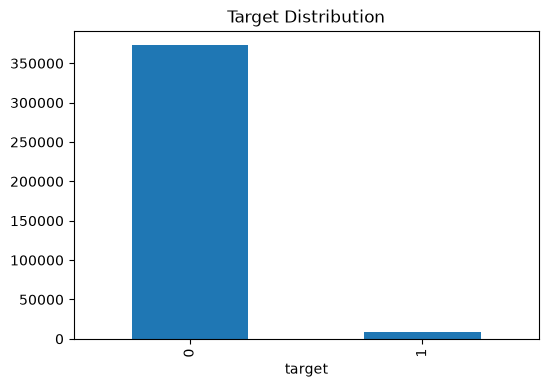

In [27]:
plt.figure(figsize=(6,4))

dataset["target"]\
    .value_counts()\
    .plot(kind="bar")

plt.title("Target Distribution")

plt.show()

## Correlation Analysis

In [29]:
numeric = dataset.select_dtypes(
    include="number"
)

In [30]:
corr = numeric.corr()

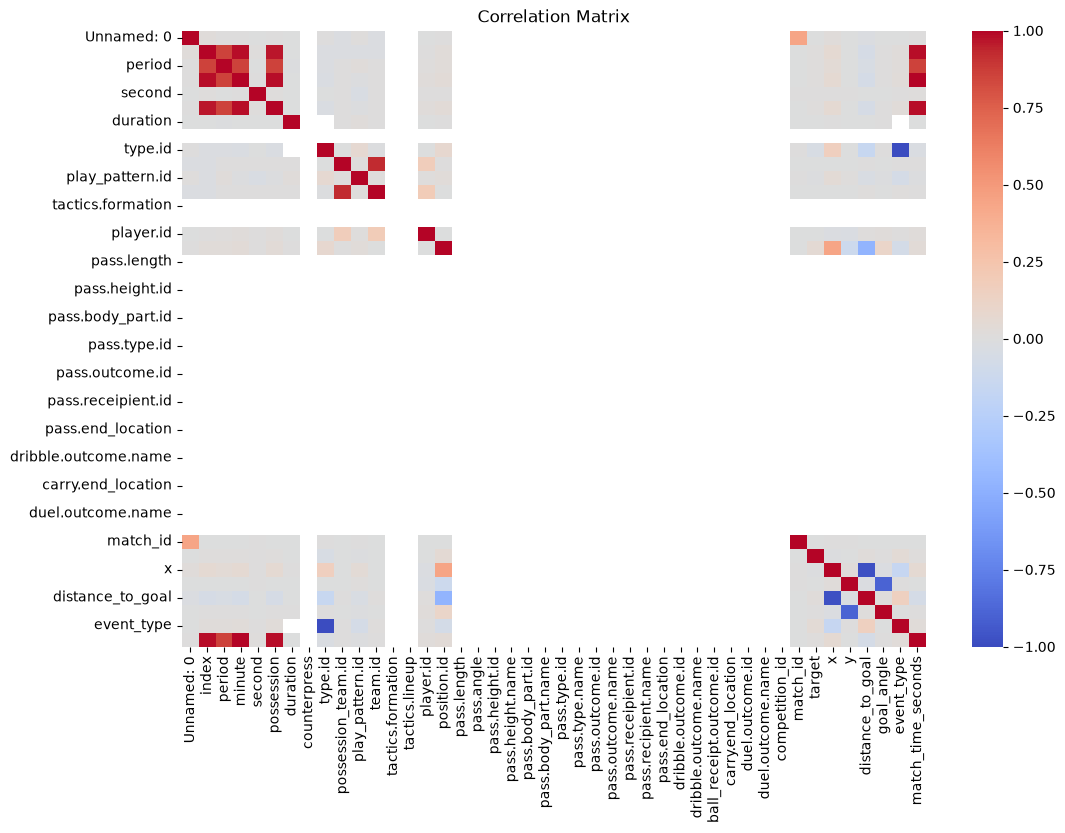

In [33]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    cmap="coolwarm",
)

plt.title("Correlation Matrix")

plt.show()

## Save Engineered Dataset

In [34]:
engineer.save_dataset(dataset)

2026-07-08 22:44:56 | INFO | Engineered dataset saved to C:\Users\91900\Teamwork_Online\epl-foul-prediction\data\processed\engineered_dataset.csv


WindowsPath('C:/Users/91900/Teamwork_Online/epl-foul-prediction/data/processed/engineered_dataset.csv')

In [35]:
engineered = pd.read_csv(
    "../data/processed/engineered_dataset.csv"
)

engineered.head()

,Unnamed: 0,id,index,period,timestamp,minute,second,possession,duration,related_events,...,competition_id,match_id,target,x,y,distance_to_goal,goal_angle,pitch_zone,event_type,match_time_seconds
0,88200,e7f3536d-3209-4ed2-a3a4-cd1519e44f7f,6,1,00:00:00.898,0,0,2,NaN,b1c7e9af-19b2-47d8-855f-14aa3209648c,...,2,3753972,0,60.2,40.7,59.804097,-0.670656,Middle,0,0
1,88203,ec0b4585-41ad-4ada-817c-629d0866eeeb,9,1,00:00:01.808,0,1,2,NaN,"575d8b5a-1b10-4f34-98df-579cc0a52a2e, 70fc4868...",...,2,3753972,0,52.4,41.6,67.618932,-1.355860,Middle,0,1
2,88206,5244092d-6381-41a2-9ea8-727bc84aa5e6,12,1,00:00:04.502,0,4,2,NaN,3d440f32-9181-4e21-8d9d-f6993914f36c,...,2,3753972,0,33.2,60.9,89.280737,-13.538167,Defensive,0,4
3,88209,38650027-fd3b-42be-8fc3-d1a23c617665,15,1,00:00:06.655,0,6,2,NaN,234fa315-2c07-44f5-a31b-d993a98ce386,...,2,3753972,0,28.5,31.1,91.931823,5.555556,Defensive,0,6
4,88212,133fb108-6aff-45d7-8311-770dfc2d4810,18,1,00:00:10.480,0,10,2,NaN,f50a6695-4769-4c8b-a0cf-473df4d91dcf,...,2,3753972,0,26.8,60.2,95.363934,-12.229037,Defensive,0,10


In [38]:
engineered.shape

(381267, 57)

## Summary & Key Insights

### Objective Achieved

In this phase, the target dataset generated during **Phase 2** was transformed into a machine learning-ready dataset through feature engineering. Spatial, temporal, and event-based features were extracted from the raw StatsBomb event data to provide meaningful predictors for the foul-win classification model.

---

## Features Engineered

The following features were successfully created:

| Feature | Description |
|----------|-------------|
| **x** | Event x-coordinate extracted from the StatsBomb location field |
| **y** | Event y-coordinate extracted from the StatsBomb location field |
| **distance_to_goal** | Euclidean distance from the event location to the opponent's goal |
| **goal_angle** | Angle between the event location and the center of the opponent's goal |
| **pitch_zone** | Categorization of the pitch into Defensive, Middle, and Attacking thirds |
| **event_type** | Numerical encoding of candidate event types (Ball Receipt* = 0, Ball Recovery = 1) |
| **match_time_seconds** | Match time converted into elapsed seconds |

---

## Dataset Summary

- Original dataset shape: **381,267 × 50**
- Engineered dataset shape: **381,267 × 57**
- New features created: **7**
- Candidate event types:
  - Ball Receipt*
  - Ball Recovery

No observations were removed during feature engineering, ensuring complete preservation of the target dataset.

---

## Distribution Insights

### Pitch Zones

- Most candidate events occurred in the **Middle Third** of the pitch.
- The **Attacking Third** contained fewer events than the middle zone.
- The **Defensive Third** had the lowest number of candidate events.

This indicates that ball receptions and recoveries are concentrated in midfield, where possession transitions frequently occur.

---

### Event Types

The engineered dataset consists of two candidate event types:

- **Ball Receipt***
- **Ball Recovery**

Ball Receipt* events represent the majority of observations, indicating that players receive possession considerably more often than they recover loose balls.

---

### Spatial Features

#### Distance to Goal

The distance-to-goal distribution spans the full length of the pitch, with the majority of candidate events occurring in midfield areas rather than immediately in front of goal.

#### Goal Angle

Goal angles are centered around zero and are approximately symmetric, reflecting event locations distributed across both sides of the pitch.

---

### Temporal Features

The match time distribution shows events occurring throughout the full duration of matches, with increased event density around halftime due to kickoff and restart events.

---

## Correlation Analysis

The correlation matrix indicates:

- Strong positive relationships between engineered spatial variables such as **x-coordinate**, **distance to goal**, and **goal angle**.
- Most engineered features exhibit relatively low pairwise correlation, suggesting that they capture complementary aspects of player actions.
- No severe multicollinearity is observed among the engineered numerical features, making them suitable for downstream machine learning models.

---

## Missing Values

The engineered features (`x`, `y`, `distance_to_goal`, `goal_angle`, `pitch_zone`, `event_type`, and `match_time_seconds`) were successfully generated without introducing additional missing values.

Existing missing values are inherited from the original StatsBomb dataset and occur primarily in optional event-specific attributes that are not applicable to every event type.

---

## Validation

The feature engineering pipeline was successfully validated by:

- Extracting valid event coordinates
- Computing spatial features
- Encoding categorical event types
- Creating temporal features
- Verifying feature distributions
- Saving the engineered dataset
- Passing all automated PyTest unit tests

---

## Output

The engineered dataset was successfully saved for the next stage of the project:

```text
data/processed/engineered_dataset.csv
```

This dataset will serve as the input for **Phase 4 – Model Training**, where machine learning models will be trained to predict whether a player who receives or recovers possession will subsequently win a foul during the same possession.